Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Dataset Preview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Logistic Regression Accuracy: 0.7951219512195122
Random Forest Accuracy: 0.9853658536585366

Best Performing Model: Random Forest


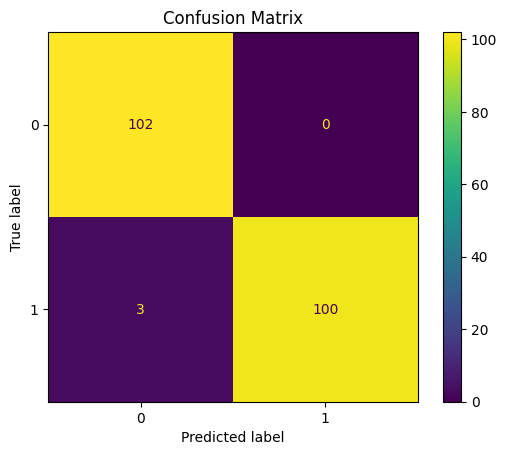

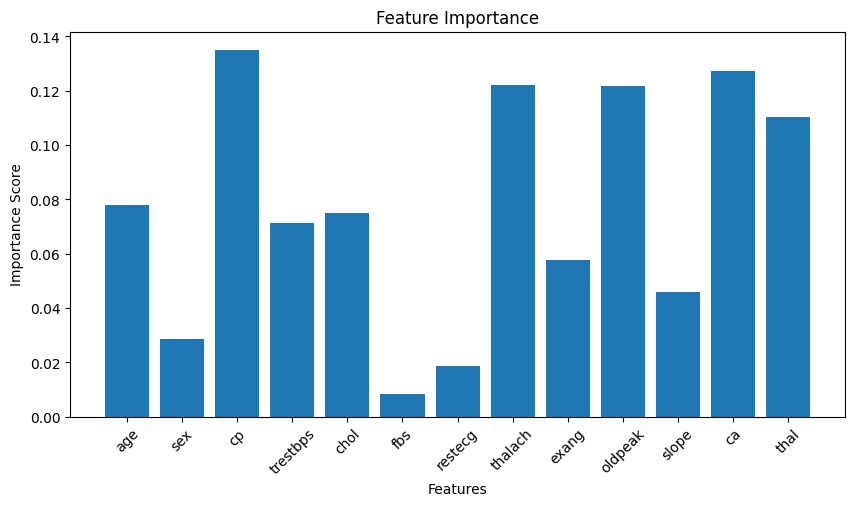


Prediction: Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
# Install dataset library
!pip install kagglehub -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Download dataset
import kagglehub

path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

# Load CSV
import os

for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)

df = pd.read_csv(csv_path)

print("Dataset Preview:")
print(df.head())

# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Logistic Regression Model
# -------------------------
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("\nLogistic Regression Accuracy:", lr_accuracy)

# -------------------------
# Random Forest Model
# -------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

# -------------------------
# Best Model Selection
# -------------------------
if rf_accuracy > lr_accuracy:
    best_model = "Random Forest"
else:
    best_model = "Logistic Regression"

print("\nBest Performing Model:", best_model)

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

# -------------------------
# Feature Importance
# -------------------------
importance = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.bar(features, importance)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

# -------------------------
# Predict New Patient
# -------------------------
sample_patient = [52,1,2,140,230,0,1,150,0,1.2,2,0,2]

prediction = rf_model.predict([sample_patient])

if prediction[0] == 1:
    print("\nPrediction: Heart Disease Detected")
else:
    print("\nPrediction: No Heart Disease")